<a href="https://colab.research.google.com/github/esmailiankian/Carotid-Artery-Plaque-CNN/blob/main/Kaggle_ColorDoppler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
import os

# 1. Download the data
path = kagglehub.dataset_download("pahunichoudhary/carotid-artery-ultrasound-and-color-doppler")

# 2. Print the path so we know where it is
print("Dataset is located at:", path)

# 3. See what folders are inside
print("Folders in this dataset:", os.listdir(path))

Using Colab cache for faster access to the 'carotid-artery-ultrasound-and-color-doppler' dataset.
Dataset is located at: /kaggle/input/carotid-artery-ultrasound-and-color-doppler
Folders in this dataset: ['Carotid artery dataset']


First using Operating System to loading and getting the data from Kaggle.
Data Visualizition using "glob" library.
First let us assume that the file format is ".jpg"
Let us see how many images and ".csv" file we have in the directory


In [6]:
import glob

# Search for all .jpg images and the .csv file inside the path
all_jpg_files = glob.glob(os.path.join(path, "**/*.jpg"), recursive=True)
all_csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)

print(f"I found {len(all_jpg_files)} images!")
if all_csv_files:
    csv_path = all_csv_files[0]
    print(f"I found the CSV at: {csv_path}")
else:
    print("I couldn't find the CSV. We might need to look for an .xlsx or check the folder manually.")

I found 0 images!
I found the CSV at: /kaggle/input/carotid-artery-ultrasound-and-color-doppler/Carotid artery dataset/Carotid_dataset.csv


As can be seen the file does not have any jpg file, so they may have different format
We need to be case sensetive as well

In [7]:
# Search for images with different extensions and cases
extensions = ['*.jpg', '*.JPG', '*.png', '*.PNG', '*.jpeg']
all_jpg_files = []

for ext in extensions:
    found = glob.glob(os.path.join(path, "**/" + ext), recursive=True)
    all_jpg_files.extend(found)

print(f"I found {len(all_jpg_files)} total images!")

# Let's see the names of the first 3 images to check the naming convention
if len(all_jpg_files) > 0:
    print("\nFirst 3 image paths:")
    for p in all_jpg_files[:3]:
        print(p)

I found 129 total images!

First 3 image paths:
/kaggle/input/carotid-artery-ultrasound-and-color-doppler/Carotid artery dataset/APB016/CD/APB016CDLC01.png
/kaggle/input/carotid-artery-ultrasound-and-color-doppler/Carotid artery dataset/APB016/CD/APB016CDRC01.png
/kaggle/input/carotid-artery-ultrasound-and-color-doppler/Carotid artery dataset/APB016/UL/APB016ULRC01.png


Data Visualization

In [8]:
import pandas as pd

# Use the path we found in the previous step
csv_path = "/kaggle/input/carotid-artery-ultrasound-and-color-doppler/Carotid artery dataset/Carotid_dataset.csv"
df = pd.read_csv(csv_path)

# This will show the table of patient information
df.head()

,Patient,Age,Weight,Gender,Height,Smoking_status,Drinking_status,Thyroid_status,Daibetes_status,Heart_diseases,Surgery_history,Cancer_history,Carotid_Plaque
0,APB001,20,51,F,168,1,1,0.0,0,0,0,0,0
1,APB002,20,76,M,188,1,1,0.0,0,0,0,0,0
2,APB003,22,64,M,182,1,1,0.0,0,0,0,0,0
3,APB004,77,60,M,164,0,0,0.0,0,1,1,0,1
4,APB005,72,56,F,150,0,0,1.0,1,0,0,0,1


Plot the Data

B-mode and Color Doppler image visualization

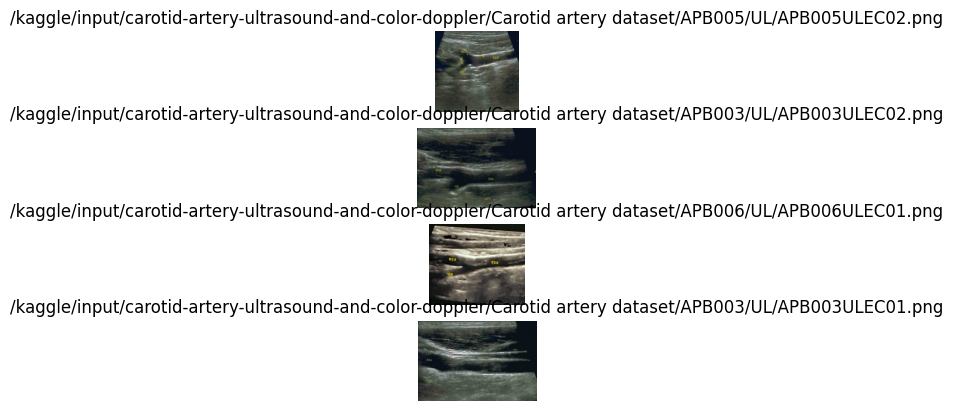

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

random_samples = random.sample(all_jpg_files,4)

plt.figure

for i, img_path in enumerate (random_samples):
  img = mpimg.imread(img_path)

  plt.subplot(4,1,i+1)
  plt.imshow(img)

  filename = os.path.basename(img_path)
  plt.title(img_path)
  plt.axis('off')

plt.show()


In [10]:
b_mode_image = []
color_doppler_image = []

for path in all_jpg_files:
  filename = os.path.basename(path)

  if "UL" in filename:
    b_mode_image.append(path)
  elif "CD" in filename:
    color_doppler_image.append(path)

print(f"Sorting")
print(f"Found {len(b_mode_image)} in the B mode")
print(f"Found {len(color_doppler_image)} in Color Doppler")


Sorting
Found 69 in the B mode
Found 60 in Color Doppler


Classification

Lable of each patient

In [11]:
labels = []
final_b_mode_paths = []


for img_path in b_mode_image:
  filename = os.path.basename(img_path)

  patient_ID = filename[:6]
  patient_row = df[df['Patient'] == patient_ID]

  if not patient_row.empty:
    status = patient_row['Carotid_Plaque'].values[0]

    labels.append(status)
    final_b_mode_paths.append(img_path)

print(f"Success! We have {len(final_b_mode_paths)} images matched with {len(labels)} labels.")

# Let's see the first 5 labels to make sure they are numbers (0 or 1)
print("First 5 labels:", labels[:5])

Success! We have 69 images matched with 69 labels.
First 5 labels: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]


Pre-Procesing

Read + Resizing + Normalizing

Original image shape was unknown.
New image shape: (224, 224)
Max pixel value: 0.788235294117647


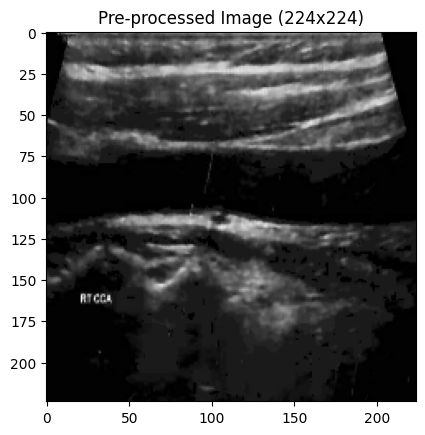

In [13]:
import cv2
import numpy as np

def preprocess_image(image_path):
  img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

  img_resized = cv2.resize(img,(224,224))

  img_normalized = img_resized/255.0

  return img_normalized

test_img = preprocess_image(final_b_mode_paths[0])

print(f"Original image shape was unknown.")
print(f"New image shape: {test_img.shape}")
print(f"Max pixel value: {test_img.max()}") # Should be <= 1.0

plt.imshow(test_img,cmap = 'gray')
plt.title("Pre-processed Image (224x224)")
plt.show()

In [14]:
all_processed_images = []

for path in final_b_mode_paths:
  processed_img = preprocess_image(path)
  all_processed_images.append(processed_img)

X = np.array(all_processed_images)
y = np.array(labels)

print("Data is ready!")
print(f"Final shape of X: {X.shape}") # Should be (69, 224, 224)
print(f"Final shape of y: {y.shape}") # Should be (69,)

Data is ready!
Final shape of X: (69, 224, 224)
Final shape of y: (69,)


Test Train Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

X_train = np.expand_dims(X_train,axis = -1)
X_test = np.expand_dims(X_test,axis = -1)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (55, 224, 224, 1)
Testing set: (14, 224, 224, 1)


Build CNN model

In [19]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu', input_shape=(224, 224, 1)),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPool2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,630,593 (21.48 MB)

 Trainable params: 5,630,593 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
hist = model.fit(X_train,y_train,epochs=15,batch_size=8,validation_data=(X_train,y_train))

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7818 - loss: 0.6579 - val_accuracy: 0.7818 - val_loss: 0.4833
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 974ms/step - accuracy: 0.7818 - loss: 0.5014 - val_accuracy: 0.7818 - val_loss: 0.4611
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7818 - loss: 0.4423 - val_accuracy: 0.7818 - val_loss: 0.3833
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 890ms/step - accuracy: 0.7818 - loss: 0.3670 - val_accuracy: 0.7818 - val_loss: 0.3313
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 884ms/step - accuracy: 0.7818 - loss: 0.2900 - val_accuracy: 0.7818 - val_loss: 0.2337
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8545 - loss: 0.2122 - val_accuracy: 0.9636 - val_loss: 0.1725
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 897ms/step - accuracy: 0.9636 - loss: 0.1488 - val_accuracy: 1.0000 - val_loss: 0.0920
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 883ms/step - accuracy: 1.0000 - loss: 0.0734 - val_accuracy: 1.0000 - val_loss: 0.032

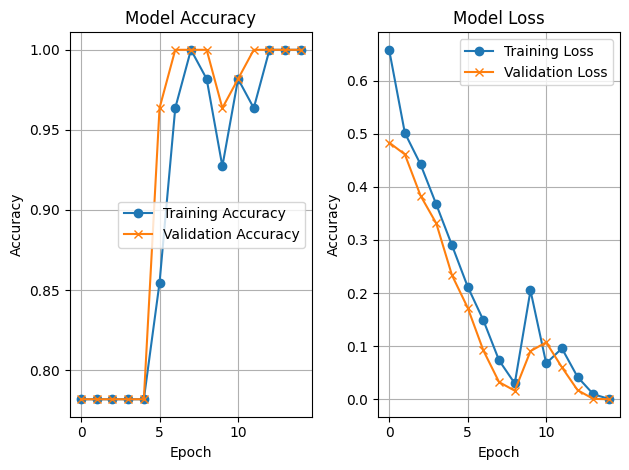

In [24]:
import matplotlib.pyplot as plt

plt.figure

plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(hist.history['val_accuracy'], label = 'Validation Accuracy', marker = 'x')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(hist.history['loss'], label='Training Loss', marker='o')
plt.plot(hist.history['val_loss'], label = 'Validation Loss', marker = 'x')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluate Model

In [26]:
test_loss, test_accuracy = model.evaluate(X_test,y_test,verbose=0)

print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Accuracy: 78.57%
Final Test Loss: 1.0394


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step


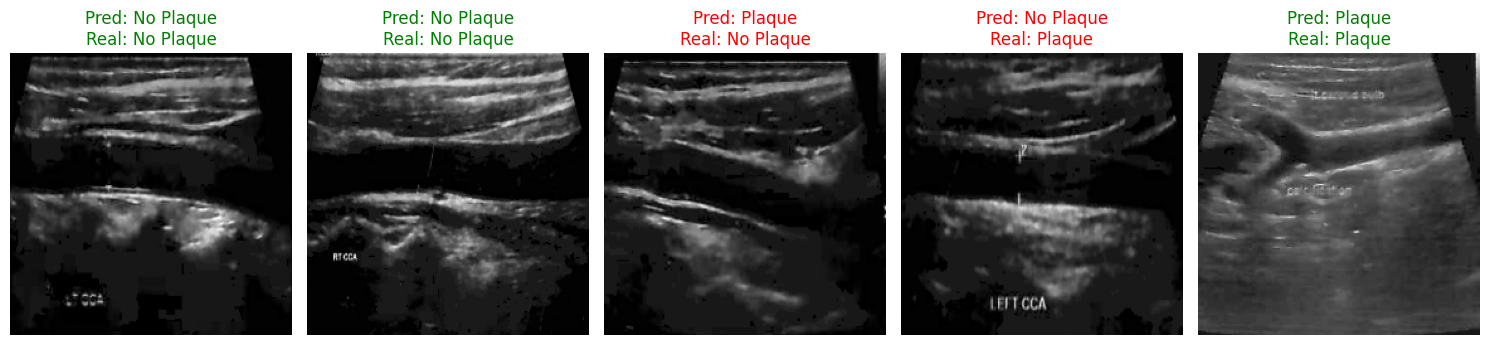

In [27]:
# 1. Get predictions for the test set
# Predictions will be between 0 and 1 (probabilities)
predictions = model.predict(X_test)

plt.figure(figsize=(15, 8))

# 2. Plot 5 test images with their predicted labels
for i in range(5):
    plt.subplot(1, 5, i + 1)

    # Show the image (remove the extra channel dimension for plotting)
    plt.imshow(X_test[i].squeeze(), cmap='gray')

    # AI's guess: round to 0 or 1
    pred_label = "Plaque" if predictions[i] > 0.5 else "No Plaque"
    # Real answer
    real_label = "Plaque" if y_test[i] == 1 else "No Plaque"

    # Color code the title: Green for correct, Red for wrong
    color = 'green' if pred_label == real_label else 'red'

    plt.title(f"Pred: {pred_label}\nReal: {real_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()